# Analisis de reseñas de `miempresa`

Este notebook realiza un analisis completo con estos objetivos:

0. Extraccion y Limpieza de datos
1. Analizar el **sentimiento global** de las reseñas.
2. Descubrir **topics**.
3. Medir **sentimiento por topic**.
4. Comparar topics vs otras empreesas dentro de la misma categoria
5. Conclusiones

## 1) Librerias

Si te falta alguna libreria, puedes instalarla con:

```bash
pip install datasets pandas numpy scikit-learn transformers torch
```

In [1]:
import re
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from transformers import pipeline

import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.text import Text
import nltk

/Users/pepecontreras/Desktop/EntornoVC/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) Configuracion

- `MAX_ROWS`: limita filas para pruebas rapidas.
- `TARGET`: dominio de la compania objetivo.
- `N_TOPICS`: numero de temas a extraer.

In [2]:
MAX_ROWS = None  # Ejemplo: 5000 para pruebas rapidas
TARGET = "www.tobycarvery.co.uk"
CAT = "Restaurants & Bars"
N_TOPICS = 8
TOP_WORDS = 12
MIN_TOPIC_DOCS = 10

## 3) Carga de datos

Cargamos el dataset desde Hugging Face y lo convertimos a DataFrame.

In [3]:

df = pd.read_csv("trustpilot-reviews-123k.csv")
df.head(3)

,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5


## 4) Observamos qué tipo de caracteres hay
Observamos primero que tipo de caracteres nos vamos a encontrar en las reseñas para que nos ayude a construir una funcion de limpieza.

In [4]:
# Muestra aleatoria para ver con tus propios ojos
df['review'].sample(10).tolist()

['I regularly buy Carnilove into the Wild from Trusty Pets, for both my Maltese dog & 3 cats. They have the best range of this dried food to match my pets breeds, small dog and sterilised for my adult cats. I won’t switch to another brand of dried food as this is over 70% meat content compared to high street brands of less than 4%! This company never fails to have what I need & I always receive a well packaged delivery, generally the day after I’ve ordered it via standard delivery. They always have the best price for the brand too. Can’t fault them at all & will continue to buy from them. ',
 'Good company to deal with and offers good deals',
 "We were amazed that the agency was able to organize a nanny for us at the last minute. We put in a request at 9 am and the nanny was able to come over by noon. The individual looking after our 2-year-old son was great and extremely professional. I highly recommend Hotel Nanny if you need someone reliable urgently. We're so thankful!",
 'It was a

In [5]:
# Longitud de reseñas
df['review_len'] = df['review'].str.len()
df['review_len'].describe()

count    123181.000000
mean        358.787305
std         314.553061
min          10.000000
25%         177.000000
50%         290.000000
75%         440.000000
max        9956.000000
Name: review_len, dtype: float64

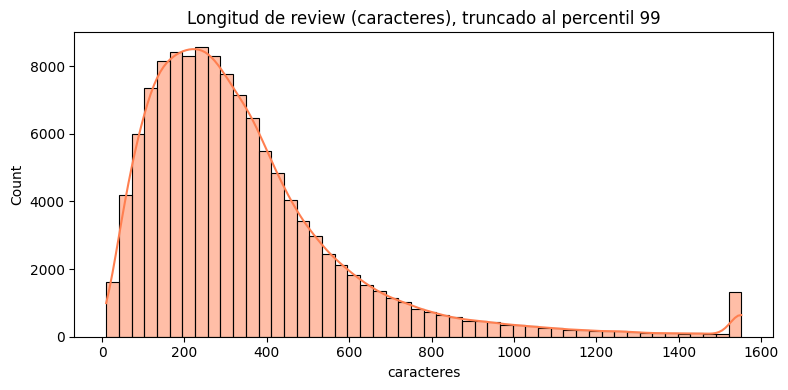

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

rl = df["review"].astype(str).str.len()
plt.figure(figsize=(8, 4))
sns.histplot(rl.clip(upper=rl.quantile(0.99)), bins=50, kde=True, color="coral")
plt.title("Longitud de review (caracteres), truncado al percentil 99")
plt.xlabel("caracteres")
plt.tight_layout()
plt.show()

## 5) Observamos que tipos de caracteres tenemos y Construimos la funcion de limpieza



In [7]:
nltk.download('stopwords')

def limpiar_texto(texto):
    texto = texto.replace("\n", " ")  # Eliminar saltos de línea
    texto = texto.lower()  # Convertir a minúsculas
    texto = re.sub(r'[^\w\s]', '', texto)  # Eliminar signos de puntuación
    stop_words = set(stopwords.words('english'))
    texto = " ".join(word for word in texto.split() if word not in stop_words)  # Eliminar stopwords
    return texto

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/pepecontreras/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 6) Filtrado del sector de la compañía objetivo

Filtramos por sector

In [8]:
df_category = df[df['category'] == CAT]

In [9]:
len(df_category)

5204

## 7) Sentimiento
Aplicamos la funcion de limpieza y el sentimiento


#### 7.1) Filtrado por compañía objetivo

In [10]:
df_category['review'] = df_category['review'].apply(limpiar_texto)

In [11]:
df_mycompany = df[df['company'] == TARGET]

In [12]:
df_mycompany['review'] = df_mycompany['review'].apply(limpiar_texto)

In [13]:
# Sentimiendo de mi compañía con transformers
import torch
from transformers import pipeline

clf = pipeline(
    'sentiment-analysis',
    model = "distilbert-base-uncased-finetuned-sst-2-english"
)

# Calcular sentimiento
def obtener_sentimiento(texto):
  texto = str(texto)[:512]
  return clf(texto)[0]

df_mycompany['sentiment_score'] = df_mycompany['review'].apply(obtener_sentimiento)

# Separación etiqueta y score
df_mycompany['label'] = df_mycompany['sentiment_score'].apply(lambda x: x['label'])
df_mycompany['score'] = df_mycompany['sentiment_score'].apply(lambda x: x['score'])

print(df_mycompany[['title', 'label', 'score']].head())

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 9102.26it/s]


                                          title     label     score
51050           Friendly atmosphere, tasty food  POSITIVE  0.999840
51051                       Toby Carvery Hinton  POSITIVE  0.999833
51052                     Xmas dinner at Tobys   POSITIVE  0.999690
51053  Really lovely food as always definitely…  POSITIVE  0.999862
51054                great food and experience   POSITIVE  0.993992


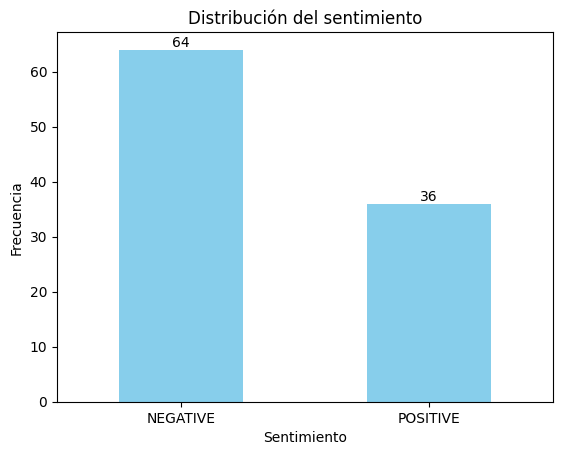

In [14]:
plt.figure()

ax = df_mycompany['label'].value_counts().plot(kind='bar', color='skyblue')

plt.xlabel('Sentimiento')
plt.ylabel('Frecuencia')
plt.title('Distribución del sentimiento')
plt.xticks(rotation=0)

for p in ax.patches:
  ax.annotate(int(p.get_height()),(p.get_x() + p.get_width() / 2., p.get_height()),
              ha='center', va='bottom')
plt.show()

In [15]:
# Sentimiendto de la competencia

df_category['sentiment_score'] = df_category['review'].apply(obtener_sentimiento)

# Separación etiqueta y score
df_category['label'] = df_category['sentiment_score'].apply(lambda x: x['label'])
df_category['score'] = df_category['sentiment_score'].apply(lambda x: x['score'])

print(df_category[['title', 'label', 'score']].head())

                                                   title     label     score
49908           Big up to my guy Moses who works in the…  POSITIVE  0.999542
49909                Great experience at itsu thanks to…  POSITIVE  0.999673
49910               As Itsu virgins we enjoyed a lovely…  POSITIVE  0.999735
49911  ITSU at Brunswick Centre: three cheers for the...  POSITIVE  0.998382
49912                         Itsu Reading Gate is Great  POSITIVE  0.999287


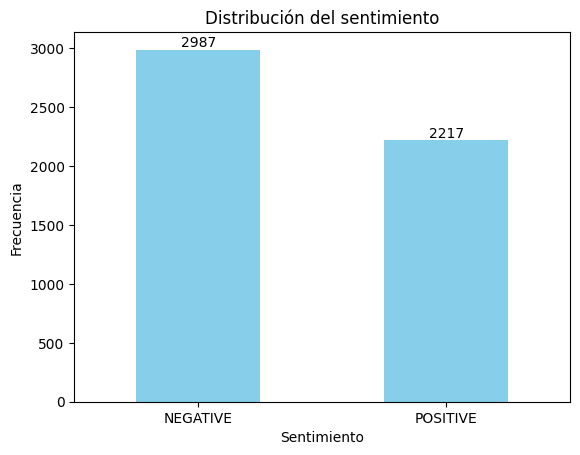

In [16]:
plt.figure()

bx = df_category['label'].value_counts().plot(kind='bar', color='skyblue')

plt.xlabel('Sentimiento')
plt.ylabel('Frecuencia')
plt.title('Distribución del sentimiento')
plt.xticks(rotation=0)

for p in bx.patches:
  bx.annotate(int(p.get_height()),(p.get_x() + p.get_width() / 2., p.get_height()),
              ha='center', va='bottom')
plt.show()

## 8) Topics



Ahora podemos explorar los tópicos generados y sus palabras clave.

In [17]:
%pip install --no-deps bertopic
%pip install --upgrade numpy hdbscan umap-learn pandas scikit-learn tqdm plotly pyyaml
# Y reinicia kernel

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [18]:
# Sustracción de topics de mi compañía
df_mycompany['review'] = df_mycompany['review'].dropna().astype(str).tolist()
len(df_mycompany['review']), df_mycompany['review'][:3]

(100,
 51050    friendly atmosphere staff friendly food amazin...
 51051    toby carvery hintonfood good atmosphere good m...
 51052    young man seb brilliant manager everyone else ...
 Name: review, dtype: str)

In [19]:
from bertopic import BERTopic
from umap import UMAP

# Aplicamos semilla para que no nos salgan valores de forma aleatoria
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# Modelo de Bertopic
topic_model = BERTopic(
    umap_model=umap_model,
    language="english",
    min_topic_size=8,
    calculate_probabilities=True,
    verbose=True,
)

In [20]:
# BERTOPIC aplicado a mi compañía para encontrar los tópicos más nombrados en las reseñas
topics, probs = topic_model.fit_transform(df_mycompany['review'])

df_mycompany['topic'] = topics

# Print topic info to debug and confirm topics found
topic_info_myCompany = topic_model.get_topic_info()

2026-04-18 17:08:35,155 - BERTopic - Embedding - Transforming documents to embeddings.
2026-04-18 17:08:35,156 - BERTopic - Automatically selecting lightweight scikit-learn embedding backend as sentence-transformers appears to not be installed.
2026-04-18 17:08:35,172 - BERTopic - Embedding - Completed ✓
2026-04-18 17:08:35,172 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-18 17:08:38,166 - BERTopic - Dimensionality - Completed ✓
2026-04-18 17:08:38,166 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-18 17:08:38,170 - BERTopic - Cluster - Completed ✓
2026-04-18 17:08:38,171 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-18 17:08:38,177 - BERTopic - Representation - Completed ✓


In [21]:
topic_info_myCompany = topic_model.get_topic_info()
topic_info_myCompany.head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,50,-1_toby_carvery_food_staff,"[toby, carvery, food, staff, meal, one, good, ...",[distracted staffkept waiting seated always lo...
1,0,27,0_good_food_carvery_meat,"[good, food, carvery, meat, staff, toby, great...",[visited toby carvery couple times recently ha...
2,1,15,1_christmas_arrived_get_waitress,"[christmas, arrived, get, waitress, told, mana...",[first time ever christmas dinner cooked last ...
3,2,8,2_breakfast_always_eat_however,"[breakfast, always, eat, however, 595, food, v...",[booked breakfast santa toby northampton thoug...


In [22]:
# Sentimiento de los topics detectados

df_mycompany['topic'] = topics
df_mycompany.groupby('topic').size()
df_mycompany.groupby('topic')['score'].mean()

pd.crosstab(df_mycompany['topic'], df_mycompany['label'])

label,NEGATIVE,POSITIVE
topic,,
-1,31,19
0,12,15
1,15,0
2,6,2


In [23]:
# Sustracción de topics de toda la categoría, para detectar los de la competencia
df_category['review'] = df_category['review'].dropna().astype(str).tolist()
len(df_category['review']), df_category['review'][:3]

(5204,
 49908    big guy moses works itsu gatwick airport kindg...
 49909    great experience itsu thanks hospitality moses...
 49910    itsu virgins enjoyed lovely first time experie...
 Name: review, dtype: str)

In [24]:
# BERTOPIC aplicado a toda la categoría
topics, probs = topic_model.fit_transform(df_category['review'])
df_category['topic'] = topics
topic_info_category = topic_model.get_topic_info()

2026-04-18 17:08:38,208 - BERTopic - Embedding - Transforming documents to embeddings.
2026-04-18 17:08:38,250 - BERTopic - Embedding - Completed ✓
2026-04-18 17:08:38,251 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-18 17:08:47,092 - BERTopic - Dimensionality - Completed ✓
2026-04-18 17:08:47,093 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-18 17:08:47,654 - BERTopic - Cluster - Completed ✓
2026-04-18 17:08:47,656 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-18 17:08:47,728 - BERTopic - Representation - Completed ✓


In [25]:
topic_info_category = topic_model.get_topic_info()
topic_info_category.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2635,-1_food_good_would_service,"[food, good, would, service, one, staff, order...",[used visit restaurant regularly food always a...
1,0,183,0_table_bar_us_staff,"[table, bar, us, staff, minutes, drinks, manag...",[went bar last night clapham junction celebrat...
2,1,181,1_email_received_customer_response,"[email, received, customer, response, sent, em...",[update touch happy response thank ordered ite...
3,2,156,2_order_placed_delivered_delivery,"[order, placed, delivered, delivery, ordered, ...","[easy order, received order confirmation week ..."
4,3,138,3_great_delivery_food_service,"[great, delivery, food, service, product, flav...","[great product fast delivery, great biltong al..."
5,4,109,4_small_portion_like_sizes,"[small, portion, like, sizes, one, portions, t...",[review based first box hello fresh meals abso...
6,5,100,5_meals_meal_cost_ingredients,"[meals, meal, cost, ingredients, two, week, qu...",[ive ordered dining experience excellent excit...
7,6,93,6_options_due_stars_variety,"[options, due, stars, variety, great, week, fi...",[love gusto made life much easierwe using gust...
8,7,79,7_new_dishes_years_also,"[new, dishes, years, also, try, year, curry, r...",[someone gluten intolerant looking nutritious ...
9,8,66,8_amazing_recommend_service_food,"[amazing, recommend, service, food, highly, de...",[visited first time friday evening cannot faul...


In [26]:
df_category['topic'] = topics
df_category.groupby('topic').size()
df_category.groupby('topic')['score'].mean()

topic
-1     0.969937
 0     0.981193
 1     0.981607
 2     0.978160
 3     0.967180
         ...   
 72    0.982740
 73    0.994627
 74    0.990463
 75    0.997864
 76    0.995423
Name: score, Length: 78, dtype: float64

In [27]:
pd.crosstab(df_category['topic'], df_category['label'])

label,NEGATIVE,POSITIVE
topic,,
-1,1530,1105
0,166,17
1,167,14
2,121,35
3,39,99
...,...,...
72,3,5
73,0,8
74,3,5


In [28]:
# Buscamos los topics de nuestra compañía entre los de la categoría para comprobar como funciona la competencia
pd.crosstab(df_category['topic'], df_category['label'])

# En este caso serían los topic 8, 10 y 13
topics_of_interest = [8, 10, 13]
df_filtered_topics = df_category[df_category['topic'].isin(topics_of_interest)]

tabla_sentimiento_filtered = pd.crosstab(df_filtered_topics['topic'], df_filtered_topics['label'])

# Map topic IDs to descriptive names
topic_names_map = {
    8: 'Good Food',
    10: 'Christmmas',
    13: 'Breakfast'
}
tabla_sentimiento_filtered.index = tabla_sentimiento_filtered.index.map(topic_names_map)

# Comprobamos el sentimiendo de los topics de nuestra compañía con respecto de la competencia
display(tabla_sentimiento_filtered)

label,NEGATIVE,POSITIVE
topic,,
Good Food,6,60
Christmmas,40,19
Breakfast,32,13


# 9) Visualizaciones

In [29]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [30]:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# stopwords extra por si quieres limpiar aún más
extra_stopwords = {
    "toby", "carvery", "restaurant", "place", "one", "would",
    "could", "really", "also", "good", "great", "nice"
}

def plot_topic_wordcloud_from_bertopic(topic_model, topic_id, titulo=None):
    topic_words = topic_model.get_topic(topic_id)

    if topic_words is None:
        print(f"No hay palabras para el topic {topic_id}")
        return

    # topic_words es lista de tuplas: [('food', 0.08), ('meat', 0.06), ...]
    freq = {
        word: score
        for word, score in topic_words
        if word not in extra_stopwords
    }

    if not freq:
        print(f"No quedan palabras tras filtrar en topic {topic_id}")
        return

    wc = WordCloud(
        width=1000,
        height=400,
        background_color="white"
    ).generate_from_frequencies(freq)

    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(titulo or f"Topic {topic_id}")
    plt.show()

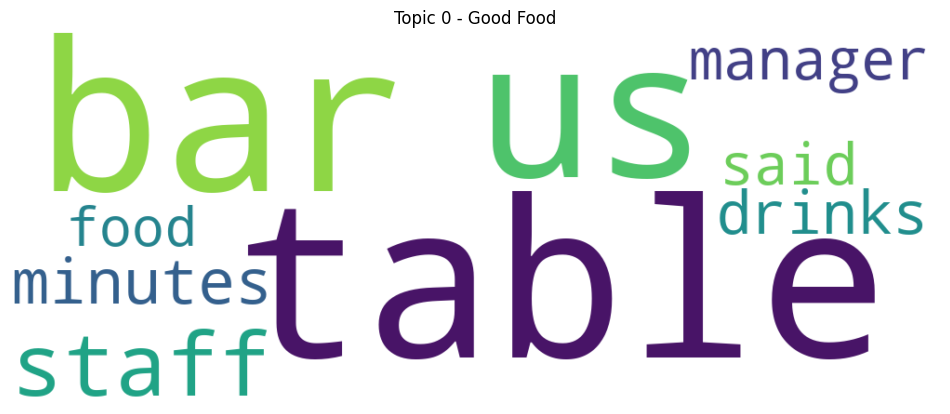

In [31]:
plot_topic_wordcloud_from_bertopic(topic_model, 0, "Topic 0 - Good Food")


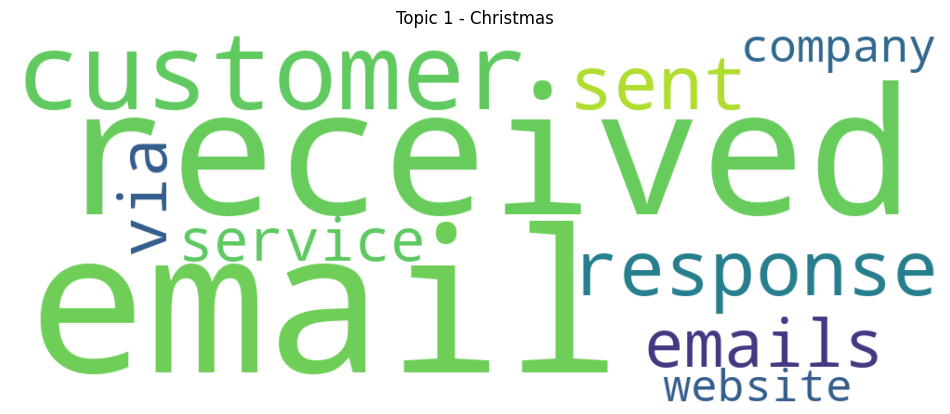

In [32]:
plot_topic_wordcloud_from_bertopic(topic_model, 1, "Topic 1 - Christmas")

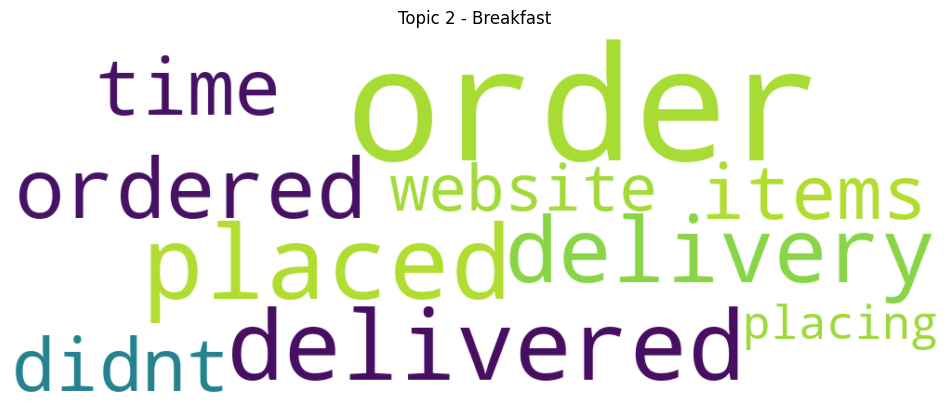

In [33]:
plot_topic_wordcloud_from_bertopic(topic_model, 2, "Topic 2 - Breakfast")